In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [4]:
data = datasets.load_digits()

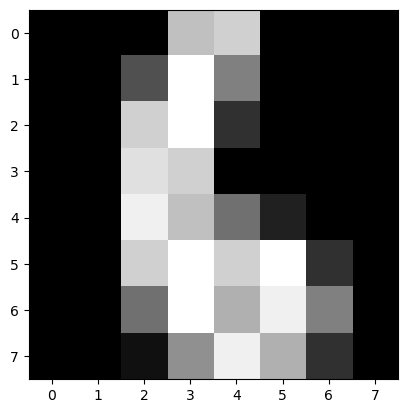

In [9]:
plt.imshow(data.images[6,:,:], cmap='gray')

In [18]:
im = data.images[6,:,:]
kernel = np.array([[1, 1],[1,1]])/4 #bigger the kernel, the more blurred
kernell = np.ones((8,8))/9

In [ ]:
from scipy.ndimage import convolve #2d version for images

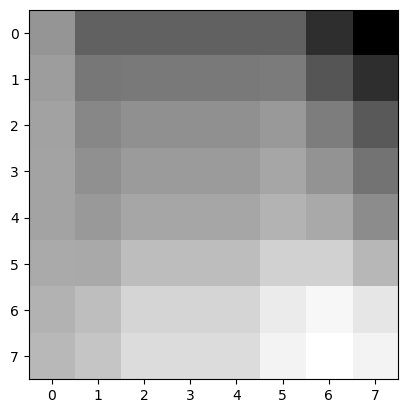

In [ ]:
im_blurred = convolve(im, kernell)
plt.imshow(im_blurred, cmap='gray') #weird things happen towards the edges

In [20]:
from sklearn.model_selection import train_test_split
import datetime

In [ ]:
#prepare inputs
images = data.images/255 #normalizing
N, W, H = images.shape #saving useful dimensions
images = images.reshape(N, W, H, 1) #1 is for color

x_train, x_test, y_train, y_test = train_test_split(images, data.target, test_size=0.3)

In [28]:
import tensorflow as tf

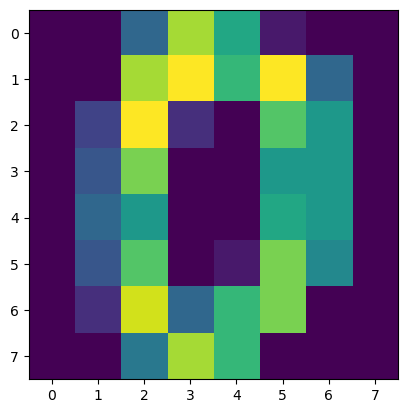

In [ ]:
plt.imshow(images[0,:,:])

In [29]:
import tensorflow as tf

In [38]:
model = tf.keras.models.Sequential()
#building the model one layer at a time

#layer 1
model.add(tf.keras.layers.Convolution2D(input_shape=(W, H, 1), 
kernel_size = 4, filters = 8, strides=1,
activation=tf.keras.activations.relu,
kernel_initializer= tf.keras.initializers.VarianceScaling())) #stide=1: pixel by pixel

#layer 2 max pooling 
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2))) #reducing the size of the image by half

# optional layer 3 &4, add on another CNN layer and Max Pooling Layer

# layer 5 -> vectorize
model.add(tf.keras.layers.Flatten()) #flattening the image to a vector

# layer 6 -> hidden layer/normal neural network
model.add(tf.keras.layers.Dense(units=128, activation=tf.keras.activations.relu)) #128 neurons in the hidden layer

# layer 7 -> dropout layer
model.add(tf.keras.layers.Dropout(0.2)) #prune 20% of the neurons

# layer 8 -> output layer
model.add(tf.keras.layers.Dense(units=10, activation=tf.keras.activations.softmax,
kernel_initializer= tf.keras.initializers.VarianceScaling())) #10 neurons for the 10 digits


/Users/henok/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary() #summary of the model

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 8)        │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,650 (22.07 KB)

 Trainable params: 5,650 (22.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model_optomizer = tf.keras.optimizers.Adam(learning_rate=0.001) #optimizer


model.compile(optimizer=model_optomizer, 
loss=tf.keras.losses.SparseCategoricalCrossentropy(), 
metrics=['accuracy']) #compiling the model



In [43]:
#training the model
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

training_history = model.fit(x_train, y_train, epochs=40,
validation_data=[x_test, y_test],
callbacks=[tensorboard_callback])


Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1095 - loss: 2.3002 - val_accuracy: 0.2130 - val_loss: 2.2874
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2501 - loss: 2.2777 - val_accuracy: 0.3426 - val_loss: 2.2476
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3876 - loss: 2.2217 - val_accuracy: 0.4444 - val_loss: 2.1585
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4867 - loss: 2.1258 - val_accuracy: 0.5093 - val_loss: 2.0075
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4924 - loss: 1.9566 - val_accuracy: 0.5389 - val_loss: 1.8036
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5462 - loss: 1.7604 - val_accuracy: 0.6389 - val_loss: 1.5816
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6045 - loss: 1.5586 - val_accuracy: 0.6796 - val_loss: 1.4166
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6482 - loss: 1.4249 - val_accuracy: 0.6833 - val_loss: